In [8]:
!pip install tensorflow

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization
from sklearn.model_selection import train_test_split


In [32]:
df= pd.read_csv('C:\\Users\\PMLS\\Documents\\All Uni Work\\Data Science & AI\\skin_disease_data\\hmnist_28_28_RGB.csv')
X= df.drop('label', axis=1).values
y= df['label'].values

df.shape

(10015, 2353)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [35]:
X_train[1,:]

array([159, 105, 143, ..., 172, 118, 153], shape=(2352,))

In [36]:
df.head()


,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [37]:
df.value_counts('label')

label
4    6705
6    1113
2    1099
1     514
0     327
5     142
3     115
Name: count, dtype: int64

In [38]:
df.shape

(10015, 2353)

Normalizing Images 


reshape(-1, 28, 28, 3) → reshapes your input data so that:

Each image is 28×28 pixels

Each pixel has 3 color channels (RGB)

-1 automatically infers the number of samples.

/ 255.0 → normalizes pixel values from 0–255 → 0–1 range.

In [42]:
X_train = X_train.reshape(-1, 28, 28, 3) 
X_test = X_test.reshape(-1, 28, 28, 3)

X_train = X_train / 255.0
X_test = X_test / 255.0

In [44]:


datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    # brightness_range=[0.9, 1.1],
    horizontal_flip=True
)

datagen.fit(X_train)


In [45]:
from tensorflow.keras import regularizers

#input shape (28 height , 28 width, 3 channels (RGB))

model = models.Sequential([
    #CNN operations
    #filters = number of feature detectors
    #kernel size = size of the feature detector 3x3
    #padding =  0; to keep the output size same as input size 

    layers.Conv2D(32, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001), input_shape=(28,28,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),


    layers.Conv2D(128,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Conv2D(128,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(256, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),


    #ANN layers --- flattening
    layers.GlobalAveragePooling2D(),
    # layers.Dense(256,activation='relu'),
    # layers.BatchNormalization(),
    # layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.BatchNormalization(),
    layers.Dense(64,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(7, activation='softmax')
])


c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
#learning rate adjustment
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)



In [47]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002)

model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [48]:
model_prediction = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),epochs=30,validation_data=(X_test, y_test),callbacks=[early_stop, checkpoint, reduce_lr])

c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 49s 138ms/step - accuracy: 0.2732 - loss: 2.4403 - val_accuracy: 0.0344 - val_loss: 4.5185 - learning_rate: 2.0000e-04
Epoch 2/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - accuracy: 0.4408 - loss: 1.9217 - val_accuracy: 0.1138 - val_loss: 5.6176 - learning_rate: 2.0000e-04
Epoch 3/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 33s 132ms/step - accuracy: 0.5252 - loss: 1.6609 - val_accuracy: 0.3100 - val_loss: 3.1203 - learning_rate: 2.0000e-04
Epoch 4/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 34s 133ms/step - accuracy: 0.5926 - loss: 1.4485 - val_accuracy: 0.6790 - val_loss: 1.2090 - learning_rate: 2.0000e-04
Epoch 5/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 155ms/step - accuracy: 0.6292 - loss: 1.3135 - val_accuracy: 0.7014 - val_loss: 1.1111 - learning_rate: 2.0000e-04
Epoch 6/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 31s 122ms/step - accuracy: 0.6510 - loss: 1.2161 - val_accuracy: 0.6710 - val_loss: 1.2121 - learning_rate: 2.0000e-04
Epoch 7/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 27s 106

In [49]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

print("Final Training Accuracy:", model_prediction.history['accuracy'][-1])

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7314 - loss: 0.9014
Test Accuracy: 0.7314028739929199
Test Loss: 0.9014325737953186
Final Training Accuracy: 0.713804304599762


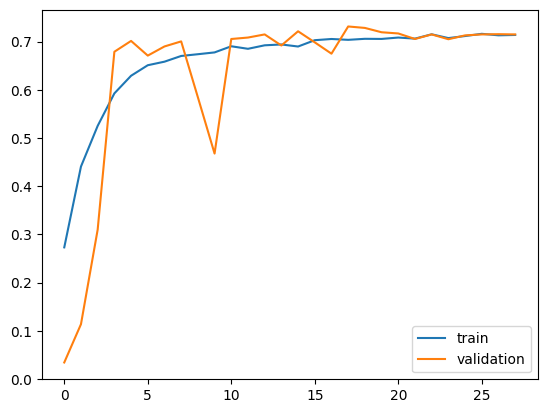

In [50]:
plt.plot(model_prediction.history['accuracy'], label='train')
plt.plot(model_prediction.history['val_accuracy'], label='validation')
plt.legend()
plt.show()